# Diffusion equation with spatial dependence

This notebook solves the 1D heterogeneous diffusion equation

$$\partial_t c = \partial_x \left( D(x) \partial_x c \right) = D(x) c_{xx} + D_x(x) c_x,$$

with $D(x) = 1.01 + \tanh(x)$ and homogeneous Dirichlet boundary conditions. It compares the existing `py-pde` reference solve with a BSPF method-of-lines solve on the same grid.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT

PosixPath('/Users/moulin/Workspace/pybspf')

## Shared Setup

We use the same domain and diffusivity in both solvers. The BSPF solve uses the expanded form $D c_{xx} + D_x c_x$ to match the stable `py-pde` formulation.

In [2]:

import matplotlib.pyplot as plt
import numpy as np
from pde import PDE, CartesianGrid, MemoryStorage, ScalarField
from scipy.integrate import solve_ivp
from pybspf import BSPF1D

domain = (-5.0, 5.0)
num_points = 128
final_time = 100
pde_dt = 1.0e-3
output_dt = 1.0
reg_param = 1.0e-8

degree = 8
n_basis = 3 * degree
num_boundary_points = degree

x = np.linspace(domain[0], domain[1], num_points)
t_eval = np.arange(0.0, final_time + 0.5 * output_dt, output_dt)

diffusivity = 1.01 + np.tanh(x)
diffusivity_x = 1.0 / np.cosh(x) ** 2

c0 = np.ones_like(x)
c0[0] = 0.0
c0[-1] = 0.0

x[:5], diffusivity[:5]

(array([-5.        , -4.92125984, -4.84251969, -4.76377953, -4.68503937]),
 array([0.0100908 , 0.01010628, 0.01012441, 0.01014562, 0.01017046]))

## py-pde Reference Solve

In [3]:
diffusivity_expr = "1.01 + tanh(x)"
term_1 = f"({diffusivity_expr}) * laplace(c)"
term_2 = f"dot(gradient({diffusivity_expr}), gradient(c))"
eq_pde = PDE({"c": f"{term_1} + {term_2}"}, bc={"value": 0})

grid_pde = CartesianGrid([[domain[0], domain[1]]], num_points, periodic=False)
field_pde = ScalarField(grid_pde, data=np.ones(grid_pde.shape))

storage_pde = MemoryStorage()
eq_pde.solve(field_pde, t_range=final_time, dt=pde_dt, tracker=storage_pde.tracker(output_dt))

t_pde = np.array(storage_pde.times)
c_history_pde = np.array([state.data for state in storage_pde])
c_history_pde.shape

(101, 128)

## BSPF Solve

In [4]:
bspf_op = BSPF1D.from_grid(
    degree=degree,
    x=x,
    n_basis=n_basis,
    domain=domain,
    use_clustering=True,
    clustering_factor=2.0,
    order=degree,
    num_boundary_points=num_boundary_points,
    correction="spectral",
)


def enforce_dirichlet_zero(c: np.ndarray) -> np.ndarray:
    c_bc = np.asarray(c, dtype=np.float64).copy()
    c_bc[0] = 0.0
    c_bc[-1] = 0.0
    return c_bc


def rhs_bspf(t: float, c: np.ndarray) -> np.ndarray:
    c_bc = enforce_dirichlet_zero(c)
    c_x, c_xx, _ = bspf_op.differentiate_1_2(c_bc, lam=reg_param)
    rhs = diffusivity * c_xx + diffusivity_x * c_x
    rhs[0] = 0.0
    rhs[-1] = 0.0
    return rhs


sol_bspf = solve_ivp(
    rhs_bspf,
    t_span=(t_eval[0], t_eval[-1]),
    y0=c0,
    t_eval=t_eval,
    method="RK45",
    max_step=0.1,
    rtol=1.0e-6,
    atol=1.0e-8,
)

c_history_bspf = np.array([enforce_dirichlet_zero(c) for c in sol_bspf.y.T])
c_history_bspf.shape

(101, 128)

## Comparison Plot

We compare the py-pde reference against the pybspf solution evolved with `solve_ivp`. Notice that py-pde is cell-centered but pybspf is nodal.

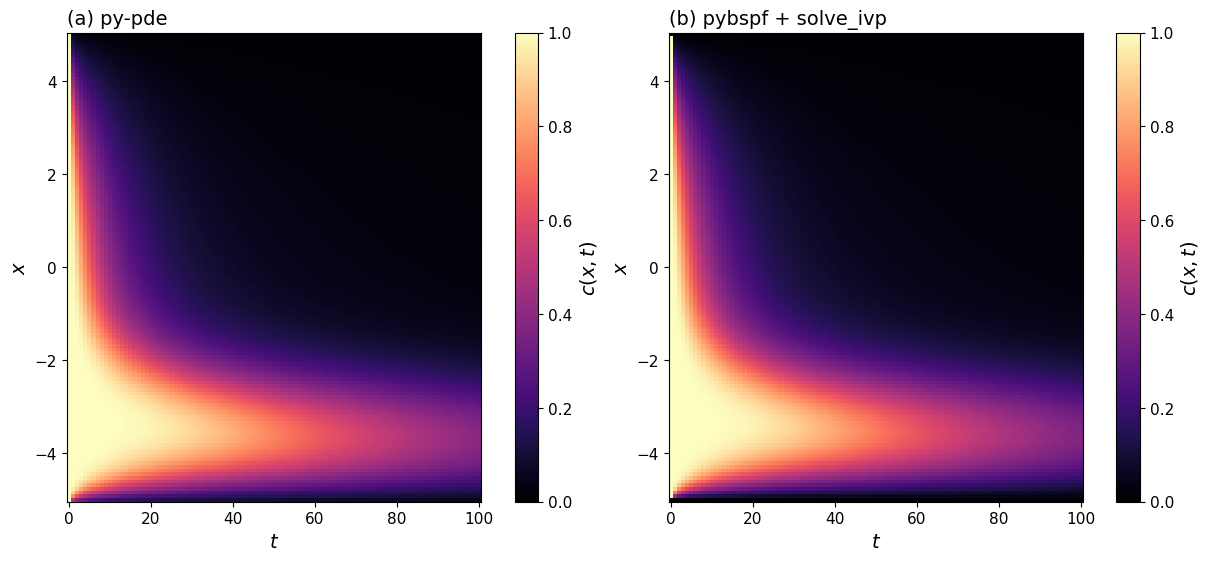

In [5]:
plt.rcParams.update(
    {
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

vmin = min(c_history_pde.min(), c_history_bspf.min())
vmax = max(c_history_pde.max(), c_history_bspf.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)

image = axes[0].pcolormesh(t_pde, x, c_history_pde.T, shading="auto", cmap="magma", vmin=vmin, vmax=vmax)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$x$")
axes[0].set_title("(a) py-pde", loc="left")
fig.colorbar(image, ax=axes[0], label="$c(x, t)$")

image = axes[1].pcolormesh(t_eval, x, c_history_bspf.T, shading="auto", cmap="magma", vmin=vmin, vmax=vmax)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$x$")
axes[1].set_title("(b) pybspf + solve_ivp", loc="left")
fig.colorbar(image, ax=axes[1], label="$c(x, t)$")

plt.show()